<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/20_regularization/20_1_Practical_Training/20_1_3_LR_Schedules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regularization: Part 3
## Learning Rate Schedules

---

## What This Notebook Is About

At the end of 20_1_2 we noted that BatchNorm lets you get away with a *larger* learning rate. This notebook takes the next step and asks a different question: should the learning rate stay the same for the whole of training at all?

A fixed learning rate is a compromise. Early in training the parameters are far from any good values, so big steps make fast progress. Late in training you are trying to settle into the bottom of a loss valley, and a step that was useful early is now too big — it carries you past the minimum and back up the other side, so the loss bounces around instead of settling. A **learning rate schedule** resolves the compromise by *changing* the learning rate over the course of training: large early, small late.

**What you will learn:**
1. Why a single fixed learning rate is a compromise — seen on a simple loss bowl
2. **Step decay** with `StepLR` — drop the learning rate by a factor every few epochs
3. **Cosine annealing** with `CosineAnnealingLR` — decay smoothly along a cosine curve
4. The `scheduler.step()` convention — where it goes in the training loop and how often
5. **Warmup** — ramping the learning rate *up* before decaying it
6. How schedules change a real training run — and an honest look at how much they help here

A note on the optimizer. Throughout this notebook we use plain **SGD**, not Adam. That is a deliberate teaching choice: this dataset is small and easy enough that Adam — whose adaptive per-parameter steps already compensate for a poorly chosen learning rate — drives the loss to nearly zero almost regardless of the schedule, which hides the effect we want to see. SGD makes the learning rate's influence direct and visible. This does **not** mean schedules are an SGD-only tool: cosine annealing with Adam (or AdamW) is the standard recipe for training modern deep networks, including the transformers in later modules. The learning rate schedule matters across the board; SGD just lets us *see* it on a problem this size.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

import seaborn as sns
sns.set_theme(style='whitegrid')
torch.manual_seed(42)

# Load the Wisconsin Breast Cancer dataset (same as 20_1_1 and 20_1_2)
data  = load_breast_cancer()
X_raw = data.data.astype(np.float32)    # 569 samples x 30 features
y_raw = data.target.astype(np.float32)  # 0=malignant, 1=benign

# Three-way split: 60% train / 20% val / 20% test (same recipe as 20_1_2).
X_tmp, X_test_np, y_tmp, y_test_np = train_test_split(
    X_raw, y_raw, test_size=0.20, stratify=y_raw, random_state=42
)
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_tmp, y_tmp, test_size=0.25, stratify=y_tmp, random_state=42  # 0.25 x 0.80 = 0.20
)

# Standardize: fit on training data only, then transform all three splits
scaler     = StandardScaler()
X_train_np = scaler.fit_transform(X_train_np)
X_val_np   = scaler.transform(X_val_np)
X_test_np  = scaler.transform(X_test_np)

# Convert to tensors; targets are shape (n, 1) to match the network's output
X_train = torch.tensor(X_train_np)
X_val   = torch.tensor(X_val_np)
X_test  = torch.tensor(X_test_np)
y_train = torch.tensor(y_train_np).unsqueeze(1)
y_val   = torch.tensor(y_val_np).unsqueeze(1)
y_test  = torch.tensor(y_test_np).unsqueeze(1)

BATCH_SIZE   = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)

print(f'Train : {X_train.shape[0]} samples')
print(f'Val   : {X_val.shape[0]} samples')
print(f'Test  : {X_test.shape[0]} samples')
print(f'Features: {X_train.shape[1]}')

Train : 341 samples
Val   : 114 samples
Test  : 114 samples
Features: 30


---

## Section 1: Why a Fixed Learning Rate Is a Compromise

Before touching the network, let's see the problem on the simplest loss surface there is: a bowl, `L(w) = w²`, whose minimum is at `w = 0`. Gradient descent there is one line — `w ← w - lr · 2w` — and it makes the role of the learning rate completely transparent.

We start at `w = 5` and run three strategies:

- a **fixed, too-large** learning rate,
- a **fixed, small** learning rate,
- a **decaying** learning rate (large, shrinking each step).

Watch where each one ends up.

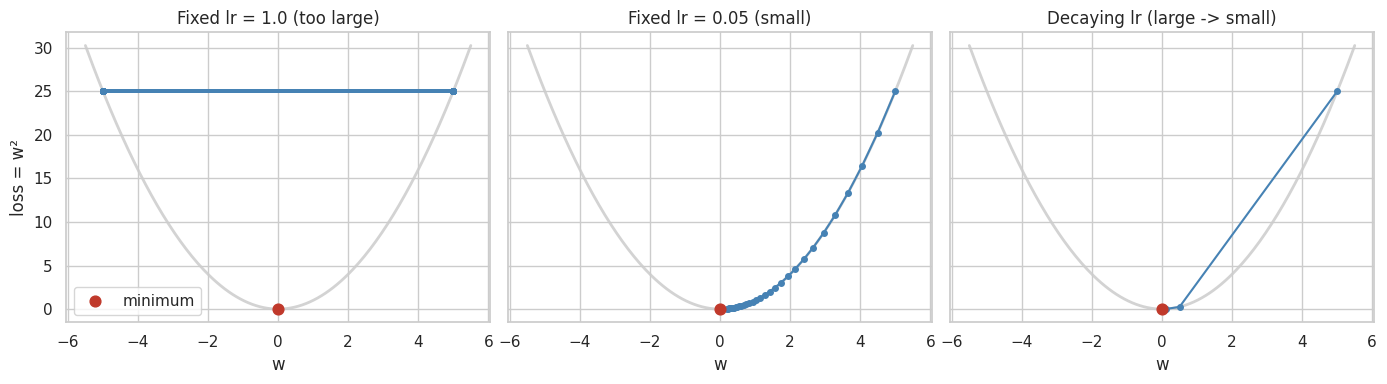

Final w after 30 steps:
  fixed lr=1.0 (too large) : +5.0000   <- ping-ponging, never settles
  fixed lr=0.05 (small)    : +0.2120   <- creeping, not there yet
  decaying lr              : +0.0005   <- big early steps, then settles


In [2]:
def descend(w0, lr_of_step, steps=30):
    """Gradient descent on L(w) = w**2 (gradient 2w). Returns the path of w."""
    w = float(w0)
    path = [w]
    for t in range(steps):
        lr = lr_of_step(t)
        w  = w - lr * (2 * w)   # SGD step on the bowl
        path.append(w)
    return path


steps = 30
path_big   = descend(5.0, lambda t: 1.0,             steps)   # fixed, too large
path_small = descend(5.0, lambda t: 0.05,            steps)   # fixed, small
path_decay = descend(5.0, lambda t: 0.45 * 0.85 ** t, steps)  # large, decaying

ws = np.linspace(-5.5, 5.5, 200)
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, path, title in [
    (axes[0], path_big,   'Fixed lr = 1.0 (too large)'),
    (axes[1], path_small, 'Fixed lr = 0.05 (small)'),
    (axes[2], path_decay, 'Decaying lr (large -> small)'),
]:
    ax.plot(ws, ws ** 2, color='lightgray', lw=2, zorder=0)
    p = np.array(path)
    ax.plot(p, p ** 2, 'o-', color='steelblue', lw=1.5, ms=4)
    ax.scatter([0], [0], color='#C0392B', s=60, zorder=5, label='minimum')
    ax.set_title(title)
    ax.set_xlabel('w')
axes[0].set_ylabel('loss = w²')
axes[0].legend()
plt.tight_layout()
plt.show()

print(f'Final w after {steps} steps:')
print(f'  fixed lr=1.0 (too large) : {path_big[-1]:+.4f}   <- ping-ponging, never settles')
print(f'  fixed lr=0.05 (small)    : {path_small[-1]:+.4f}   <- creeping, not there yet')
print(f'  decaying lr              : {path_decay[-1]:+.4f}   <- big early steps, then settles')

The three panels tell the whole story:

- **Fixed, too large.** Each step overshoots the minimum and lands on the *other* side of the bowl, exactly as far out as it started — `5 → -5 → 5 → -5 → …`. The point ping-pongs forever and makes no progress at all. This is the late-training problem in its most extreme form: a step size that is far too big for where you are.
- **Fixed, small.** No overshoot, but each step is tiny, so after 30 steps it is still crawling toward the minimum. Safe but slow.
- **Decaying.** The best of both. The first steps are large and cover ground fast (even overshooting once), then the learning rate shrinks so the later steps are small and land cleanly at the bottom.

That last strategy — **start large, shrink over time** — is exactly what a learning rate schedule does. The rest of the notebook covers the two schedules you will reach for most often, and how to wire them into a real training loop.

---

## Section 2: Step Decay with `StepLR`

The simplest schedule is **step decay**: keep the learning rate fixed for a block of epochs, then multiply it by a factor and hold it again. In PyTorch this is `torch.optim.lr_scheduler.StepLR(optimizer, step_size, gamma)` — every `step_size` epochs the learning rate is multiplied by `gamma`.

A scheduler wraps an existing optimizer. You create the optimizer as usual, hand it to the scheduler, and then call `scheduler.step()` once per epoch. Let's build one and just *read its schedule* — no training yet, only the learning rate it would produce epoch by epoch:

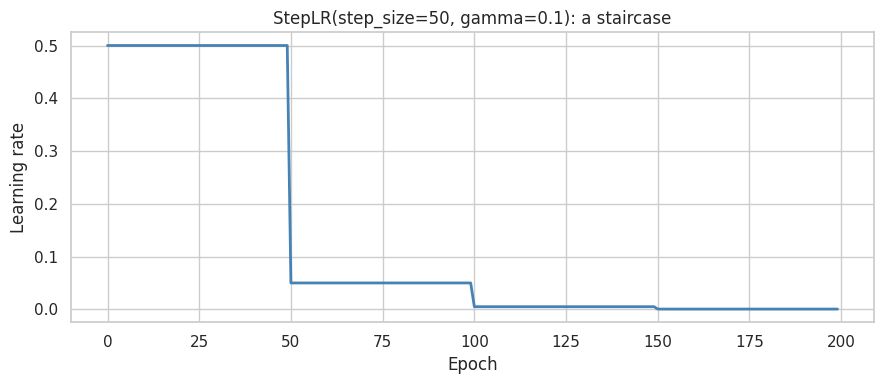

Learning rate at selected epochs:
  epoch   0: lr = 0.50000
  epoch  49: lr = 0.50000
  epoch  50: lr = 0.05000
  epoch  99: lr = 0.05000
  epoch 100: lr = 0.00500
  epoch 150: lr = 0.00050


In [3]:
demo_model = nn.Linear(30, 1)
demo_opt   = torch.optim.SGD(demo_model.parameters(), lr=0.5)
step_sched = torch.optim.lr_scheduler.StepLR(demo_opt, step_size=50, gamma=0.1)

step_lrs = []
for epoch in range(200):
    step_lrs.append(demo_opt.param_groups[0]['lr'])
    demo_opt.step()      # stands in for a real training step
    step_sched.step()    # advance the schedule once per epoch

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(step_lrs, color='steelblue', lw=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning rate')
ax.set_title('StepLR(step_size=50, gamma=0.1): a staircase')
plt.tight_layout()
plt.show()

print('Learning rate at selected epochs:')
for e in (0, 49, 50, 99, 100, 150):
    print(f'  epoch {e:3d}: lr = {step_lrs[e]:.5f}')

The learning rate is a staircase: `0.5` for the first 50 epochs, then `0.05`, then `0.005`, and so on — multiplied by `gamma=0.1` at each step. Step decay is easy to understand and easy to reason about, which is why it is still common. Its downside is exactly that abruptness: the learning rate jumps by 10x in a single epoch, which can jolt the loss. The next schedule smooths that out.

---

## Section 3: Cosine Annealing with `CosineAnnealingLR`

**Cosine annealing** decays the learning rate smoothly, following the shape of a cosine curve from the starting value down to (near) zero over `T_max` epochs. `torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max)` decays slowly at first, then faster through the middle, then slowly again as it flattens out near zero. It is one of the most widely used schedules in modern deep learning. Read its schedule the same way:

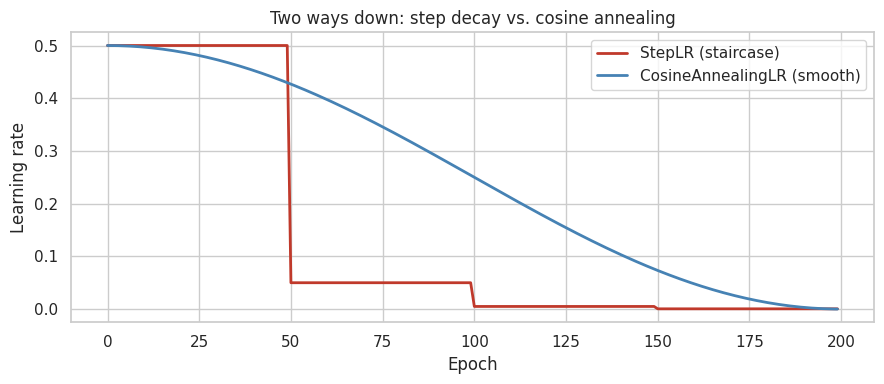

Cosine learning rate at selected epochs:
  epoch   0: lr = 0.50000
  epoch  50: lr = 0.42678
  epoch 100: lr = 0.25000
  epoch 150: lr = 0.07322
  epoch 199: lr = 0.00003


In [4]:
demo_opt2  = torch.optim.SGD(nn.Linear(30, 1).parameters(), lr=0.5)
cos_sched  = torch.optim.lr_scheduler.CosineAnnealingLR(demo_opt2, T_max=200)

cos_lrs = []
for epoch in range(200):
    cos_lrs.append(demo_opt2.param_groups[0]['lr'])
    demo_opt2.step()
    cos_sched.step()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(step_lrs, color='#C0392B',   lw=2, label='StepLR (staircase)')
ax.plot(cos_lrs,  color='steelblue', lw=2, label='CosineAnnealingLR (smooth)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning rate')
ax.set_title('Two ways down: step decay vs. cosine annealing')
ax.legend()
plt.tight_layout()
plt.show()

print('Cosine learning rate at selected epochs:')
for e in (0, 50, 100, 150, 199):
    print(f'  epoch {e:3d}: lr = {cos_lrs[e]:.5f}')

Same destination, different path. Step decay drops in sudden jumps; cosine annealing glides down continuously. Because there are no abrupt jumps, the loss tends to descend more smoothly under cosine annealing — there is no epoch where the learning rate suddenly changes by an order of magnitude.

---

## Section 4: The `scheduler.step()` Convention

Two rules govern where `scheduler.step()` goes, and getting them wrong is a common source of quiet bugs.

**Rule 1 — call it *after* `optimizer.step()`.** The optimizer applies the update using the current learning rate; the scheduler then sets the rate for the *next* round. Calling the scheduler first would apply tomorrow's rate to today's update.

**Rule 2 — call it once *per epoch*, outside the batch loop** (for the schedules in this notebook). `StepLR` and `CosineAnnealingLR` count in epochs: `step_size=50` means 50 epochs, and `T_max=200` means 200 epochs. If you accidentally call `scheduler.step()` inside the batch loop, it advances once per *batch* — with 11 batches per epoch, your 200-epoch cosine schedule would finish in about 18 epochs and sit at zero for the rest of training.

The skeleton, with the two calls in the right places:

```python
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

for epoch in range(200):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()       # update params with the current lr
    scheduler.step()           # AFTER optimizer.step(), ONCE per epoch
```

The training helper below follows exactly that structure. It optionally takes a `make_scheduler` function so we can run the same loop with no schedule, step decay, or cosine annealing and compare them fairly.

In [5]:
def train_with_schedule(model, optimizer, n_epochs, make_scheduler=None):
    """Canonical training loop with an optional per-epoch LR scheduler.

    make_scheduler: a function optimizer -> scheduler, or None for a fixed LR.
    Returns (train_losses, val_losses, learning_rates) per epoch."""
    criterion = nn.BCELoss()
    scheduler = make_scheduler(optimizer) if make_scheduler else None
    train_losses, val_losses, lrs = [], [], []

    for epoch in range(n_epochs):
        # --- training phase ---
        model.train()
        epoch_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        train_losses.append(epoch_loss / len(train_loader))

        # --- validation phase ---
        model.eval()
        with torch.no_grad():
            val_losses.append(criterion(model(X_val), y_val).item())

        # record the lr used this epoch, then advance the schedule
        lrs.append(optimizer.param_groups[0]['lr'])
        if scheduler is not None:
            scheduler.step()   # after optimizer.step(), once per epoch

    return train_losses, val_losses, lrs

---

## Section 5: Warmup — Ramping the Learning Rate Up First

Schedules do not have to start at the top. **Warmup** begins with a very small learning rate and ramps it *up* over the first few epochs before any decay begins. The motivation: at the very start of training the parameters are random and the gradients can be large and noisy, so a full-size step can throw the model into a bad region. Warming up lets the model find its footing before taking big steps. It is standard practice when training Transformers, which is why it is worth recognizing.

`torch.optim.lr_scheduler.LinearLR` ramps the learning rate linearly from `start_factor × base_lr` up to `base_lr` over `total_iters` epochs. Here is a warmup over the first 10 epochs, followed by holding steady:

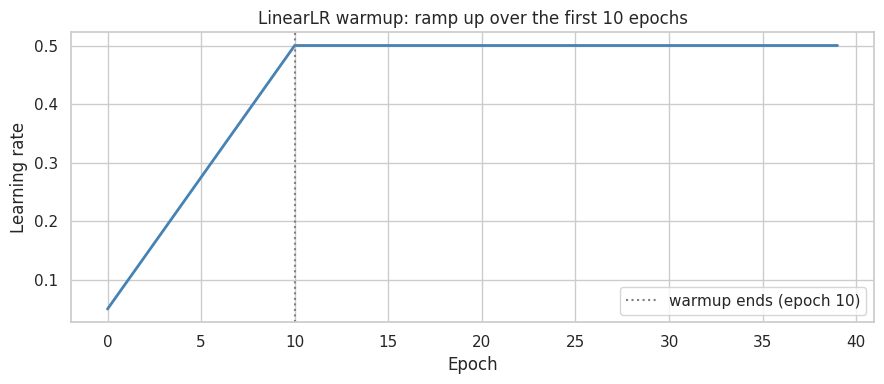

Learning rate during warmup:
  epoch  0: lr = 0.05000
  epoch  2: lr = 0.14000
  epoch  4: lr = 0.23000
  epoch  6: lr = 0.32000
  epoch  8: lr = 0.41000
  epoch 10: lr = 0.50000
  epoch 12: lr = 0.50000


In [6]:
demo_opt3 = torch.optim.SGD(nn.Linear(30, 1).parameters(), lr=0.5)
warmup    = torch.optim.lr_scheduler.LinearLR(demo_opt3, start_factor=0.1, total_iters=10)

warm_lrs = []
for epoch in range(40):
    warm_lrs.append(demo_opt3.param_groups[0]['lr'])
    demo_opt3.step()
    warmup.step()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(warm_lrs, color='steelblue', lw=2)
ax.axvline(10, color='gray', linestyle=':', label='warmup ends (epoch 10)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning rate')
ax.set_title('LinearLR warmup: ramp up over the first 10 epochs')
ax.legend()
plt.tight_layout()
plt.show()

print('Learning rate during warmup:')
for e in (0, 2, 4, 6, 8, 10, 12):
    print(f'  epoch {e:2d}: lr = {warm_lrs[e]:.5f}')

The learning rate climbs from `0.05` (that is `0.1 × 0.5`) up to the full `0.5` by epoch 10, then stays there. In practice warmup is usually *followed* by a decay schedule — ramp up, then cosine down — which PyTorch can compose with `SequentialLR`. For this small problem we keep it simple and treat warmup as a concept to recognize rather than a tool we need here.

---

## Section 6: Schedules on the Real Network

Now the comparison that matters: the same (256, 256) breast-cancer network from 20_1_2, trained three ways with plain SGD — a fixed learning rate, step decay, and cosine annealing — all starting from `lr = 0.5` and running 200 epochs. We watch the **validation** loss, because on this easy dataset the training loss is driven to nearly zero in every case and hides the difference.

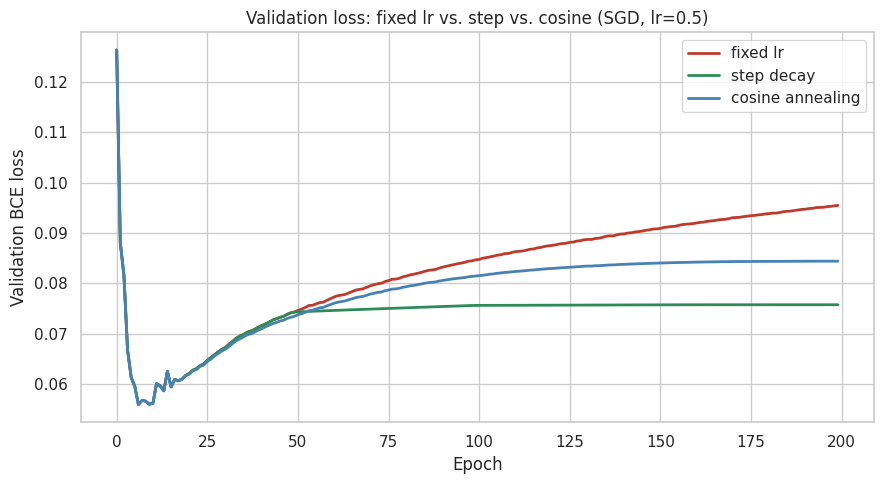

                  best val     end-of-training val
fixed lr      :    0.0560          0.0955
step decay    :    0.0560          0.0758
cosine anneal :    0.0560          0.0844


In [7]:
def make_net():
    """The (256, 256) network from 20_1_2 (no dropout/BN, to isolate the schedule)."""
    torch.manual_seed(42)
    return nn.Sequential(
        nn.Linear(30, 256), nn.ReLU(),
        nn.Linear(256, 256), nn.ReLU(),
        nn.Linear(256, 1), nn.Sigmoid(),
    )


BASE_LR, EPOCHS = 0.5, 200

# Fixed learning rate (no scheduler)
m_fixed = make_net()
fixed_tr, fixed_val, fixed_lrs = train_with_schedule(
    m_fixed, torch.optim.SGD(m_fixed.parameters(), lr=BASE_LR), EPOCHS
)

m_step = make_net()
step_tr, step_val, step_lrs_run = train_with_schedule(
    m_step, torch.optim.SGD(m_step.parameters(), lr=BASE_LR), EPOCHS,
    make_scheduler=lambda o: torch.optim.lr_scheduler.StepLR(o, step_size=50, gamma=0.1)
)

m_cos = make_net()
cos_tr, cos_val, cos_lrs_run = train_with_schedule(
    m_cos, torch.optim.SGD(m_cos.parameters(), lr=BASE_LR), EPOCHS,
    make_scheduler=lambda o: torch.optim.lr_scheduler.CosineAnnealingLR(o, T_max=EPOCHS)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(fixed_val, color='#C0392B',   lw=2, label='fixed lr')
ax.plot(step_val,  color='seagreen',  lw=2, label='step decay')
ax.plot(cos_val,   color='steelblue', lw=2, label='cosine annealing')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation BCE loss')
ax.set_title('Validation loss: fixed lr vs. step vs. cosine (SGD, lr=0.5)')
ax.legend()
plt.tight_layout()
plt.show()

print('                  best val     end-of-training val')
print(f'fixed lr      :    {min(fixed_val):.4f}          {fixed_val[-1]:.4f}')
print(f'step decay    :    {min(step_val):.4f}          {step_val[-1]:.4f}')
print(f'cosine anneal :    {min(cos_val):.4f}          {cos_val[-1]:.4f}')

Read the two columns carefully — the story is in the gap between them, and it is the same shape as the dropout story from 20_1_1.

- **All three reach essentially the same *best* validation loss.** A schedule does not find a lower floor on this problem; the network is perfectly capable of reaching its best value with a fixed learning rate.
- **The *end-of-training* loss is where they part.** With a fixed learning rate the validation loss drifts up and away from its best value — the optimizer keeps taking full-size steps near the minimum and bounces around, so where it happens to land at epoch 200 is elevated and noisy. Both schedules shrink the learning rate as training proceeds, so the late steps are small and the loss settles close to its best instead of wandering.

The practical lesson is **schedule beats fixed at the endpoint**, not "cosine beats step." The small difference between step and cosine here is well within the noise of a single split and seed — on 114 validation samples it would reorder if you changed the seed. What is robust is that *either* schedule controls the late-epoch drift that a fixed rate leaves uncontrolled. This is the same role checkpointing and early stopping play in 20_1_4: a schedule keeps the endpoint near the good region; checkpointing captures the best point regardless.

---

## Section 7: Final Evaluation on the Test Set

We close the loop on the untouched **test set**, training a fresh network with cosine annealing on the combined train+validation data.

In [8]:
# Combine train + validation for the final fit
X_trainval = torch.cat([X_train, X_val])
y_trainval = torch.cat([y_train, y_val])
trainval_loader = DataLoader(
    TensorDataset(X_trainval, y_trainval), batch_size=BATCH_SIZE, shuffle=True
)

final_model = make_net()
final_optim = torch.optim.SGD(final_model.parameters(), lr=BASE_LR)
final_sched = torch.optim.lr_scheduler.CosineAnnealingLR(final_optim, T_max=EPOCHS)
final_crit  = nn.BCELoss()

for epoch in range(EPOCHS):
    final_model.train()
    for X_b, y_b in trainval_loader:
        final_optim.zero_grad()
        loss = final_crit(final_model(X_b), y_b)
        loss.backward()
        final_optim.step()
    final_sched.step()   # after optimizer steps, once per epoch

final_model.eval()
with torch.no_grad():
    test_preds  = (final_model(X_test) > 0.5).long().squeeze().numpy()
    test_labels = y_test.long().squeeze().numpy()

print('Final model: (256, 256) SGD + cosine annealing')
print()
print(classification_report(test_labels, test_preds, target_names=data.target_names, digits=3))

Final model: (256, 256) SGD + cosine annealing

              precision    recall  f1-score   support

   malignant      0.911     0.976     0.943        42
      benign      0.986     0.944     0.965        72

    accuracy                          0.956       114
   macro avg      0.948     0.960     0.954       114
weighted avg      0.958     0.956     0.956       114



---

## Putting It All Together

| Concept | What it means |
|---|---|
| Learning rate schedule | Changing the learning rate over training: large early for fast progress, small late to settle |
| `StepLR(step_size, gamma)` | Step decay — multiply the lr by `gamma` every `step_size` epochs (a staircase) |
| `CosineAnnealingLR(T_max)` | Smoothly decay the lr along a cosine curve from the start value to ~0 over `T_max` epochs |
| `scheduler.step()` | Call it **after** `optimizer.step()`, **once per epoch** for these schedulers |
| Warmup (`LinearLR`) | Ramp the lr *up* over the first few epochs before decaying — standard for Transformers |
| What a schedule fixes | Not the best-case loss, but the late-epoch drift: it keeps the endpoint near the good region |

**The habits to lock in:** put `scheduler.step()` after `optimizer.step()` and call it once per epoch; reach for cosine annealing as a sensible default; and remember that a schedule's payoff is a clean, controlled *endpoint*, not a lower floor.

**What is coming next:** Notebook 20_1_4 covers **saving and checkpointing** — how to write a trained model to disk, load it back, and implement *early stopping*, which captures the best epoch during training. That is the natural partner to everything in this module: dropout and schedules widen and stabilize the window of good epochs, and checkpointing is how you keep the best one.